In [2]:
import pandas as pd
df = pd.read_excel('raw_data_nckh.xlsx')

In [3]:
df

,thoi_gian,gioi_tinh,tuoi,trinh_do,nghe_nghiep,thu_nhap,thoi_gian_su_dung,dich_vu_thuong_dung,SQ1,SQ2,...,TR1,TR2,TR3,TR4,TR5,TR6,CS1,CS2,CS3,CS4
0,2025-12-24 13:36:02.267,Nữ,Từ 18 đến 24,Đại học,Học sinh/ Sinh viên,Dưới 5 triệu đồng,6 tháng - dưới 1 năm,Bảo hiểm xe cơ giới,2,1,...,2,1,2,3,1,1,1,2,2,1.0
1,2025-12-26 20:38:40.621,Nữ,Từ 18 đến 24,Đại học,Học sinh/ Sinh viên,Không muốn tiết lộ,Dưới 6 tháng,Bảo hiểm xe cơ giới,3,3,...,3,3,3,2,2,3,3,3,3,3.0
2,2025-12-26 20:50:48.919,Nữ,Từ 18 đến 24,Đại học,Nhân viên văn phòng,10 - dưới 20 triệu đồng,6 tháng - dưới 1 năm,Bảo hiểm sức khỏe,3,3,...,3,3,3,3,3,3,3,3,3,3.0
3,2025-12-26 20:59:36.255,Nữ,Từ 18 đến 24,Đại học,Học sinh/ Sinh viên,Dưới 5 triệu đồng,6 tháng - dưới 1 năm,Bảo hiểm sức khỏe,4,4,...,4,4,4,4,4,4,4,4,4,4.0
4,2025-12-26 21:05:25.634,Nữ,Từ 18 đến 24,Đại học,Học sinh/ Sinh viên,5 - dưới 10 triệu đồng,Dưới 6 tháng,Bảo hiểm du lịch,1,1,...,1,3,4,2,2,3,3,2,4,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424,2026-01-19 00:26:00.994,Nữ,Từ 35 đến 44,Đại học,Kinh doanh/ Tự do,Từ 20 triệu đồng trở lên,1 - dưới 3 năm,Bảo hiểm tài sản/nhà ở,4,5,...,4,4,5,5,4,4,4,4,5,4.0
425,2026-01-19 00:27:15.866,Nữ,Từ 45 đến 54,Đại học,Nhân viên văn phòng,Từ 20 triệu đồng trở lên,1 - dưới 3 năm,Bảo hiểm du lịch,4,3,...,4,4,5,4,4,4,4,4,4,4.0
426,2026-01-19 00:28:35.086,Nữ,Từ 25 đến 34,Đại học,Kinh doanh/ Tự do,Từ 20 triệu đồng trở lên,6 tháng - dưới 1 năm,Bảo hiểm xe cơ giới,4,3,...,4,5,5,4,5,5,4,5,5,4.0
427,2026-01-19 00:30:16.766,Nữ,Từ 35 đến 44,Đại học,Nhân viên văn phòng,10 - dưới 20 triệu đồng,1 - dưới 3 năm,Bảo hiểm du lịch,4,4,...,5,5,5,4,4,3,5,5,5,4.0


In [4]:
# Kiểm tra thông tin dữ liệu
print("Thông tin DataFrame:")
print(df.info())
print("\n" + "="*50 + "\n")
print("Số lượng giá trị null:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")
print("5 dòng đầu tiên:")
print(df.head())

Thông tin DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   thoi_gian            429 non-null    datetime64[ns]
 1   gioi_tinh            429 non-null    object        
 2   tuoi                 429 non-null    object        
 3   trinh_do             429 non-null    object        
 4   nghe_nghiep          429 non-null    object        
 5   thu_nhap             429 non-null    object        
 6   thoi_gian_su_dung    429 non-null    object        
 7   dich_vu_thuong_dung  429 non-null    object        
 8   SQ1                  429 non-null    int64         
 9   SQ2                  429 non-null    int64         
 10  SQ3                  429 non-null    int64         
 11  SQ4                  429 non-null    int64         
 12  SQ5                  429 non-null    int64         
 13  IQ1           

# Làm sạch dữ liệu

## Các bước làm sạch:
1. Xử lý giá trị null/missing values
2. Loại bỏ duplicates (dòng trùng lặp)
3. Chuẩn hóa kiểu dữ liệu
4. Xử lý outliers (giá trị ngoại lai)
5. Chuẩn hóa text (nếu có cột text)

In [5]:
## 1. Xử lý giá trị null/missing values
# Tạo bản sao để làm sạch
df_clean = df.copy()

# Kiểm tra tỷ lệ giá trị null trong mỗi cột
print("Tỷ lệ % giá trị null trong mỗi cột:")
null_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
print(null_percentage[null_percentage > 0].sort_values(ascending=False))
print("\n" + "="*50 + "\n")

# Các phương pháp xử lý null:
# Option 1: Xóa các dòng có giá trị null (nếu không nhiều)
# df_clean = df_clean.dropna()

# Option 2: Điền giá trị null với giá trị trung bình (cho cột số)
# df_clean['column_name'] = df_clean['column_name'].fillna(df_clean['column_name'].mean())

# Option 3: Điền giá trị null với giá trị trung vị (cho cột số)
df_clean['PEOU4'] = df_clean['PEOU4'].fillna(df_clean['PEOU4'].median())
df_clean['CS4'] = df_clean['CS4'].fillna(df_clean['CS4'].median())

# Option 4: Điền giá trị null với giá trị xuất hiện nhiều nhất (cho cột phân loại)
# df_clean['column_name'] = df_clean['column_name'].fillna(df_clean['column_name'].mode()[0])

# Option 5: Forward fill - điền giá trị trước đó
# df_clean = df_clean.fillna(method='ffill')

print(f"Số dòng trước khi xử lý null: {len(df)}")
print(f"Số dòng sau khi xử lý null: {len(df_clean)}")

Tỷ lệ % giá trị null trong mỗi cột:
PEOU4    0.4662
CS4      0.2331
dtype: float64


Số dòng trước khi xử lý null: 429
Số dòng sau khi xử lý null: 429


In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   thoi_gian            429 non-null    datetime64[ns]
 1   gioi_tinh            429 non-null    object        
 2   tuoi                 429 non-null    object        
 3   trinh_do             429 non-null    object        
 4   nghe_nghiep          429 non-null    object        
 5   thu_nhap             429 non-null    object        
 6   thoi_gian_su_dung    429 non-null    object        
 7   dich_vu_thuong_dung  429 non-null    object        
 8   SQ1                  429 non-null    int64         
 9   SQ2                  429 non-null    int64         
 10  SQ3                  429 non-null    int64         
 11  SQ4                  429 non-null    int64         
 12  SQ5                  429 non-null    int64         
 13  IQ1                  429 non-null  

In [7]:
## 2. Loại bỏ duplicates (dòng trùng lặp)
print(f"Số dòng trùng lặp: {df_clean.duplicated().sum()}")

# Xóa dòng trùng lặp (giữ lại lần xuất hiện đầu tiên)
df_clean = df_clean.drop_duplicates()

print(f"Số dòng sau khi xóa duplicates: {len(df_clean)}")

Số dòng trùng lặp: 0
Số dòng sau khi xóa duplicates: 429


In [8]:
## 3. Chuẩn hóa kiểu dữ liệu
print("Kiểu dữ liệu của các cột:")
print(df_clean.dtypes)
print("\n" + "="*50 + "\n")

# Ví dụ chuyển đổi kiểu dữ liệu:
# df_clean['column_name'] = df_clean['column_name'].astype('int')
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])

# Chuyển đổi cột text thành lowercase (nếu cần)
# df_clean['text_column'] = df_clean['text_column'].str.lower()

# Loại bỏ khoảng trắng thừa
#df_clean['text_column'] = df_clean['text_column'].str.strip()

Kiểu dữ liệu của các cột:
thoi_gian              datetime64[ns]
gioi_tinh                      object
tuoi                           object
trinh_do                       object
nghe_nghiep                    object
thu_nhap                       object
thoi_gian_su_dung              object
dich_vu_thuong_dung            object
SQ1                             int64
SQ2                             int64
SQ3                             int64
SQ4                             int64
SQ5                             int64
IQ1                             int64
IQ2                             int64
IQ3                             int64
IQ4                             int64
SVQ1                            int64
SVQ2                            int64
SVQ3                            int64
SVQ4                            int64
SVQ5                            int64
PEOU1                           int64
PEOU2                           int64
PEOU3                           int64
PEOU4                   

In [9]:
## 4. Xử lý outliers (giá trị ngoại lai) - chỉ áp dụng cho cột số
import numpy as np

# Chọn cột số để xử lý
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns

print("Các cột số trong dataset:")
print(list(numeric_columns))
print("\n" + "="*50 + "\n")

# Phương pháp IQR (Interquartile Range) để phát hiện outliers
for col in numeric_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)][col]
    
    if len(outliers) > 0:
        print(f"Cột '{col}': {len(outliers)} outliers ({len(outliers)/len(df_clean)*100:.2f}%)")
        
# Các phương pháp xử lý outliers:
# Option 1: Xóa các dòng có outliers
# df_clean = df_clean[~((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound))]

# Option 2: Thay thế outliers bằng giá trị median
# df_clean.loc[df_clean[col] < lower_bound, col] = df_clean[col].median()
# df_clean.loc[df_clean[col] > upper_bound, col] = df_clean[col].median()

# Option 3: Cap outliers (giới hạn trong khoảng)
# df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

Các cột số trong dataset:
['SQ1', 'SQ2', 'SQ3', 'SQ4', 'SQ5', 'IQ1', 'IQ2', 'IQ3', 'IQ4', 'SVQ1', 'SVQ2', 'SVQ3', 'SVQ4', 'SVQ5', 'PEOU1', 'PEOU2', 'PEOU3', 'PEOU4', 'PEOU5', 'PU1', 'PU2', 'PU3', 'PU4', 'TR1', 'TR2', 'TR3', 'TR4', 'TR5', 'TR6', 'CS1', 'CS2', 'CS3', 'CS4']


Cột 'SQ1': 16 outliers (3.73%)
Cột 'SQ2': 12 outliers (2.80%)
Cột 'SQ3': 11 outliers (2.56%)
Cột 'SQ4': 6 outliers (1.40%)
Cột 'SQ5': 27 outliers (6.29%)
Cột 'IQ1': 25 outliers (5.83%)
Cột 'IQ2': 21 outliers (4.90%)
Cột 'IQ4': 21 outliers (4.90%)
Cột 'SVQ2': 9 outliers (2.10%)
Cột 'SVQ4': 23 outliers (5.36%)
Cột 'SVQ5': 23 outliers (5.36%)
Cột 'PEOU1': 28 outliers (6.53%)
Cột 'PEOU3': 20 outliers (4.66%)
Cột 'PEOU4': 22 outliers (5.13%)
Cột 'PEOU5': 22 outliers (5.13%)
Cột 'PU1': 23 outliers (5.36%)
Cột 'PU2': 20 outliers (4.66%)
Cột 'PU3': 19 outliers (4.43%)
Cột 'PU4': 23 outliers (5.36%)
Cột 'TR1': 19 outliers (4.43%)
Cột 'TR2': 212 outliers (49.42%)
Cột 'TR3': 10 outliers (2.33%)
Cột 'TR5': 19 outliers (4.43%)
C

In [10]:
## 5. Kiểm tra kết quả sau khi làm sạch
print("Kết quả sau khi làm sạch:")
print(f"Số dòng ban đầu: {len(df)}")
print(f"Số dòng sau khi làm sạch: {len(df_clean)}")
print(f"Số dòng bị xóa: {len(df) - len(df_clean)}")
print("\n" + "="*50 + "\n")
print("Thông tin DataFrame sau khi làm sạch:")
print(df_clean.info())
print("\n" + "="*50 + "\n")
print("Xem dữ liệu sau khi làm sạch:")
print(df_clean.head())

Kết quả sau khi làm sạch:
Số dòng ban đầu: 429
Số dòng sau khi làm sạch: 429
Số dòng bị xóa: 0


Thông tin DataFrame sau khi làm sạch:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   thoi_gian            429 non-null    datetime64[ns]
 1   gioi_tinh            429 non-null    object        
 2   tuoi                 429 non-null    object        
 3   trinh_do             429 non-null    object        
 4   nghe_nghiep          429 non-null    object        
 5   thu_nhap             429 non-null    object        
 6   thoi_gian_su_dung    429 non-null    object        
 7   dich_vu_thuong_dung  429 non-null    object        
 8   SQ1                  429 non-null    int64         
 9   SQ2                  429 non-null    int64         
 10  SQ3                  429 non-null    int64         
 11  SQ4           

# CHƯƠNG 4. KẾT QUẢ NGHIÊN CỨU


## 4.1 Thống kê mô tả đối tượng khảo sát


Mục này trình bày đặc điểm chung của đối tượng tham gia khảo sát nhằm làm rõ tính đại diện của mẫu nghiên cứu.


In [11]:
ten_hien_thi = {
    'gioi_tinh': 'Giới tính',
    'tuoi': 'Độ tuổi',
    'trinh_do': 'Trình độ học vấn',
    'nghe_nghiep': 'Nghề nghiệp',
    'thu_nhap': 'Thu nhập',
    'thoi_gian_su_dung': 'Thời gian sử dụng dịch vụ',
    'dich_vu_thuong_dung': 'Dịch vụ bảo hiểm thường sử dụng'
}

def thong_ke_mau(df, column):
    freq = df[column].value_counts(dropna=False).reset_index()
    freq.columns = ['Nhóm', 'Tần suất']
    
    freq['Tỷ lệ (%)'] = round(freq['Tần suất'] / len(df) * 100, 2)
    freq['Đặc điểm'] = ten_hien_thi[column]
    
    return freq[['Đặc điểm','Nhóm','Tần suất','Tỷ lệ (%)']]


bang_mo_ta = pd.concat(
    [thong_ke_mau(df, col) for col in ten_hien_thi],
    ignore_index=True
)


bang_mo_ta
bang_mo_ta.to_excel('bang_mo_ta_thong_tin_chung.xlsx', index=False)

In [12]:
print("Bảng mô tả thông tin chung")
print(bang_mo_ta)

Bảng mô tả thông tin chung
                           Đặc điểm                      Nhóm  Tần suất  \
0                         Giới tính                        Nữ       262   
1                         Giới tính                       Nam       166   
2                         Giới tính                      Khác         1   
3                           Độ tuổi              Từ 18 đến 24       141   
4                           Độ tuổi              Từ 25 đến 34       127   
5                           Độ tuổi              Từ 35 đến 44        87   
6                           Độ tuổi              Từ 45 đến 54        63   
7                           Độ tuổi             Từ 55 trở lên        11   
8                  Trình độ học vấn                   Đại học       301   
9                  Trình độ học vấn                      THPT        58   
10                 Trình độ học vấn                   Thạc sĩ        37   
11                 Trình độ học vấn       Trung cấp/ Cao đẳng        24  

In [13]:
bang_mo_ta.style \
    .set_caption("Bảng 4.1: Thống kê mô tả đặc điểm đối tượng nghiên cứu") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#f2f2f2'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('text-align', 'center')]}
    ])


,Đặc điểm,Nhóm,Tần suất,Tỷ lệ (%)
0,Giới tính,Nữ,262,61.070000
1,Giới tính,Nam,166,38.690000
2,Giới tính,Khác,1,0.230000
3,Độ tuổi,Từ 18 đến 24,141,32.870000
4,Độ tuổi,Từ 25 đến 34,127,29.600000
5,Độ tuổi,Từ 35 đến 44,87,20.280000
6,Độ tuổi,Từ 45 đến 54,63,14.690000
7,Độ tuổi,Từ 55 trở lên,11,2.560000
8,Trình độ học vấn,Đại học,301,70.160000
9,Trình độ học vấn,THPT,58,13.520000


*Nhận xét*: 

🔹 Về giới tính

Kết quả khảo sát cho thấy nữ giới chiếm tỷ lệ cao nhất với 61,07%, trong khi nam giới chiếm 38,69% và nhóm giới tính khác chiếm tỷ lệ không đáng kể (0,23%). Điều này cho thấy đối tượng khảo sát có sự chênh lệch nhất định về giới tính, trong đó nữ giới là nhóm tham gia khảo sát chủ yếu.

🔹 Về độ tuổi

Xét về độ tuổi, nhóm từ 18 đến 24 tuổi chiếm tỷ lệ cao nhất (32,87%), tiếp theo là nhóm từ 25 đến 34 tuổi (29,60%). Các nhóm tuổi từ 35 đến 44 và từ 45 đến 54 lần lượt chiếm 20,28% và 14,69%, trong khi nhóm từ 55 tuổi trở lên chiếm tỷ lệ thấp nhất (2,56%). Kết quả cho thấy phần lớn người tham gia khảo sát thuộc nhóm tuổi lao động trẻ, là nhóm có mức độ tiếp cận và sử dụng các dịch vụ bảo hiểm số tương đối cao.

🔹 Về trình độ học vấn

Về trình độ học vấn, đa số người được khảo sát có trình độ đại học, chiếm 70,16%. Các nhóm có trình độ THPT, thạc sĩ, trung cấp/cao đẳng và tiến sĩ chiếm tỷ lệ lần lượt là 13,52%, 8,62%, 5,59% và 2,10%. Điều này cho thấy mẫu nghiên cứu có trình độ học vấn tương đối cao, phù hợp với việc tiếp cận và sử dụng các nền tảng bảo hiểm phi nhân thọ trong môi trường số.

🔹 Về nghề nghiệp

Xét theo nghề nghiệp, nhóm học sinh/sinh viên chiếm tỷ lệ cao nhất với 38,46%, tiếp theo là nhóm nhân viên văn phòng (22,61%). Các nhóm kinh doanh/tự do, nhóm nghề nghiệp khác và nhóm quản lý/lãnh đạo chiếm tỷ lệ lần lượt là 15,15%, 16,32% và 7,46%. Cơ cấu nghề nghiệp cho thấy mẫu khảo sát phản ánh tương đối đa dạng các nhóm khách hàng đang sử dụng dịch vụ bảo hiểm.

🔹 Về thu nhập

Về mức thu nhập, nhóm có thu nhập từ 10 đến dưới 20 triệu đồng chiếm tỷ lệ cao nhất (31,24%), tiếp theo là nhóm dưới 5 triệu đồng (29,14%). Nhóm có thu nhập từ 20 triệu đồng trở lên chiếm 18,65%, trong khi hai nhóm có thu nhập từ 5 đến dưới 10 triệu đồng và không muốn tiết lộ thu nhập cùng chiếm 10,49%. Kết quả cho thấy mức thu nhập của người tham gia khảo sát phân bố tương đối đa dạng, phản ánh nhiều phân khúc khách hàng khác nhau của thị trường bảo hiểm phi nhân thọ.

🔹 Về thời gian sử dụng dịch vụ bảo hiểm

Xét về thời gian sử dụng dịch vụ bảo hiểm, nhóm dưới 6 tháng chiếm tỷ lệ cao nhất (33,10%), tiếp theo là nhóm trên 3 năm (24,48%) và nhóm từ 1 đến dưới 3 năm (23,54%). Nhóm sử dụng dịch vụ từ 6 tháng đến dưới 1 năm chiếm 18,88%. Điều này cho thấy mẫu khảo sát bao gồm cả khách hàng mới và khách hàng đã có nhiều kinh nghiệm sử dụng dịch vụ bảo hiểm, góp phần nâng cao độ tin cậy của kết quả nghiên cứu.

🔹 Về loại dịch vụ bảo hiểm thường sử dụng

Về loại hình bảo hiểm, bảo hiểm sức khỏe là dịch vụ được sử dụng phổ biến nhất với tỷ lệ 48,02%. Tiếp theo là bảo hiểm xe cơ giới (21,91%) và bảo hiểm du lịch (15,85%). Các loại bảo hiểm khác và bảo hiểm tài sản/nhà ở chiếm tỷ lệ thấp hơn, lần lượt là 9,09% và 5,13%. Kết quả này cho thấy nhu cầu đối với các sản phẩm bảo hiểm liên quan trực tiếp đến sức khỏe và phương tiện cá nhân vẫn chiếm ưu thế trong thị trường bảo hiểm phi nhân thọ.

Nhìn chung, mẫu khảo sát có cơ cấu đa dạng về đặc điểm nhân khẩu học và hành vi sử dụng dịch vụ, phù hợp với mục tiêu và phạm vi nghiên cứu. Đây là cơ sở đảm bảo tính đại diện và độ tin cậy cho các phân tích tiếp theo trong nghiên cứu.

## 4.2 Thống kê mô tả các biến quan sát


Mục này trình bày giá trị trung bình và độ lệch chuẩn của các biến quan sát trong mô hình nghiên cứu nhằm đánh giá mức độ cảm nhận của người trả lời.


In [14]:
bien_quan_sat = {
    'Chất lượng hệ thống': ['SQ1', 'SQ2', 'SQ3', 'SQ4', 'SQ5'],
    'Chất lượng thông tin': ['IQ1', 'IQ2', 'IQ3', 'IQ4'],
    'Chất lượng dịch vụ': ['SVQ1', 'SVQ2', 'SVQ3', 'SVQ4', 'SVQ5'],
    'Nhận thức về tính dễ sử dụng': ['PEOU1', 'PEOU2', 'PEOU3', 'PEOU4', 'PEOU5'],
    'Nhận thức về tính hữu ích': ['PU1', 'PU2', 'PU3', 'PU4'],
    'Niềm tin': ['TR1', 'TR2', 'TR3', 'TR4', 'TR5', 'TR6'],
    'Sự hài lòng': ['CS1', 'CS2', 'CS3', 'CS4']
}

def bang_mo_ta_bien(df, danh_sach_bien):
    bang = df[danh_sach_bien].agg(['min','max','mean', 'std']).T.reset_index()
    bang.columns = ['Biến quan sát', 'Min', 'Max', 'Mean', 'Std. Deviation']
    return bang.round(3)

bang_SQ = bang_mo_ta_bien(df, bien_quan_sat['Chất lượng hệ thống'])
bang_IQ  = bang_mo_ta_bien(df, bien_quan_sat['Chất lượng thông tin'])
bang_SVQ = bang_mo_ta_bien(df, bien_quan_sat['Chất lượng dịch vụ'])
bang_PEOU = bang_mo_ta_bien(df, bien_quan_sat['Nhận thức về tính dễ sử dụng'])
bang_PU = bang_mo_ta_bien(df, bien_quan_sat['Nhận thức về tính hữu ích'])
bang_TR = bang_mo_ta_bien(df, bien_quan_sat['Niềm tin'])
bang_CS = bang_mo_ta_bien(df, bien_quan_sat['Sự hài lòng'])



In [15]:
print("4.2.1 Bảng thống kê mô tả yếu tố độc lập Chất lượng hệ thống")
bang_SQ

4.2.1 Bảng thống kê mô tả yếu tố độc lập Chất lượng hệ thống


,Biến quan sát,Min,Max,Mean,Std. Deviation
0,SQ1,1.0,5.0,3.709,0.970
1,SQ2,1.0,5.0,3.828,0.929
2,SQ3,1.0,5.0,3.772,0.942
3,SQ4,1.0,5.0,3.844,0.902
4,SQ5,1.0,5.0,4.142,0.986


In [16]:
print("4.2.2 Bảng thống kê mô tả yếu tố độc lập Chất lượng thông tin")
bang_IQ

4.2.2 Bảng thống kê mô tả yếu tố độc lập Chất lượng thông tin


,Biến quan sát,Min,Max,Mean,Std. Deviation
0,IQ1,1.0,5.0,4.054,0.927
1,IQ2,1.0,5.0,4.068,0.926
2,IQ3,1.0,5.0,3.879,0.899
3,IQ4,1.0,5.0,4.112,0.889


In [17]:
print("4.2.3 Bảng thống kê mô tả yếu tố độc lập Chất lượng dịch vụ")
bang_SVQ

4.2.3 Bảng thống kê mô tả yếu tố độc lập Chất lượng dịch vụ


,Biến quan sát,Min,Max,Mean,Std. Deviation
0,SVQ1,1.0,5.0,3.970,0.923
1,SVQ2,1.0,5.0,3.769,0.935
2,SVQ3,1.0,5.0,3.895,0.910
3,SVQ4,1.0,5.0,3.958,0.877
4,SVQ5,1.0,5.0,4.021,0.863


In [18]:
print("4.2.4 Bảng thống kê mô tả yếu tố độc lập Nhận thức về tính dễ sử dụng")
bang_PEOU

4.2.4 Bảng thống kê mô tả yếu tố độc lập Nhận thức về tính dễ sử dụng


,Biến quan sát,Min,Max,Mean,Std. Deviation
0,PEOU1,1.0,5.0,4.061,0.960
1,PEOU2,1.0,5.0,3.907,0.910
2,PEOU3,1.0,5.0,4.040,0.871
3,PEOU4,1.0,5.0,4.059,0.850
4,PEOU5,1.0,5.0,3.993,0.863


In [19]:
print("4.2.5 Bảng thống kê mô tả yếu tố độc lập Nhận thức về tính hữu ích")
bang_PU


4.2.5 Bảng thống kê mô tả yếu tố độc lập Nhận thức về tính hữu ích


,Biến quan sát,Min,Max,Mean,Std. Deviation
0,PU1,1.0,5.0,4.156,0.905
1,PU2,1.0,5.0,4.205,0.875
2,PU3,1.0,5.0,4.212,0.853
3,PU4,1.0,5.0,4.175,0.902


In [20]:
print("4.2.6 Bảng thống kê mô tả yếu tố độc lập Niềm tin")
bang_TR


4.2.6 Bảng thống kê mô tả yếu tố độc lập Niềm tin


,Biến quan sát,Min,Max,Mean,Std. Deviation
0,TR1,1.0,5.0,4.047,0.844
1,TR2,1.0,5.0,3.925,0.859
2,TR3,1.0,5.0,3.839,0.922
3,TR4,1.0,5.0,3.937,0.869
4,TR5,1.0,5.0,4.023,0.853
5,TR6,1.0,5.0,4.047,0.816


In [21]:
print("4.2.7 Bảng thống kê mô tả yếu tố phụ thuộc Sự hài lòng")
bang_CS

4.2.7 Bảng thống kê mô tả yếu tố phụ thuộc Sự hài lòng


,Biến quan sát,Min,Max,Mean,Std. Deviation
0,CS1,1.0,5.0,3.965,0.804
1,CS2,1.0,5.0,3.986,0.820
2,CS3,1.0,5.0,4.023,0.820
3,CS4,1.0,5.0,3.918,0.866


## 4.3 Đánh giá độ tin cậy thang đo


Cronbach’s Alpha dùng để:
- kiểm tra độ tin cậy của thang đo
- xem các biến quan sát trong cùng 1 nhân tố có đo lường cùng 1 khái niệm hay không: 
+ vd: 5 câu này có đang cùng đo MỘT khái niệm hay không?

Nếu: các câu trả lời giống hướng nhau, ai đánh giá SQ1 cao thì cũng hay đánh giá SQ2, SQ3 cao → thang đo nhất quán → đáng tin.

| Chỉ tiêu                         | Ngưỡng |
| -------------------------------- | ------ |
| Cronbach’s Alpha (tính nhất quán)| ≥ 0.7  |
| Corrected Item–Total Correlation | ≥ 0.3  | 
(đo xem một câu hỏi có “đi chung” với cả thang đo hay không)


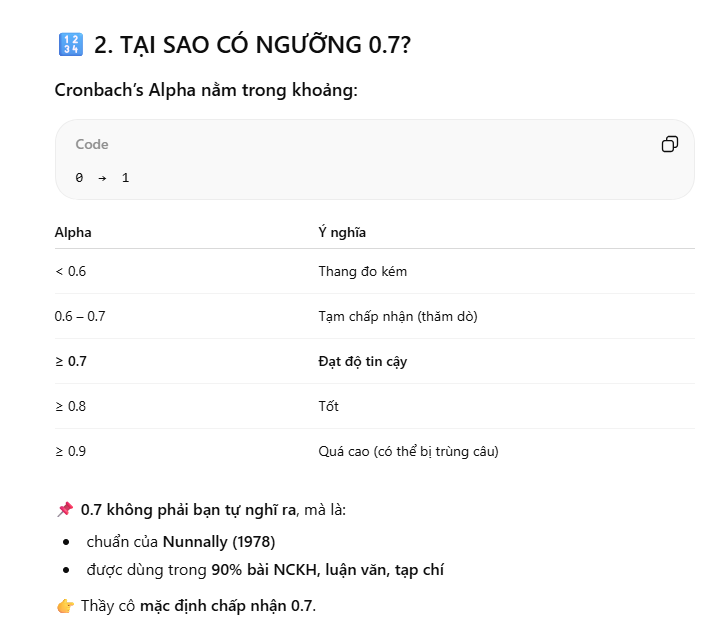

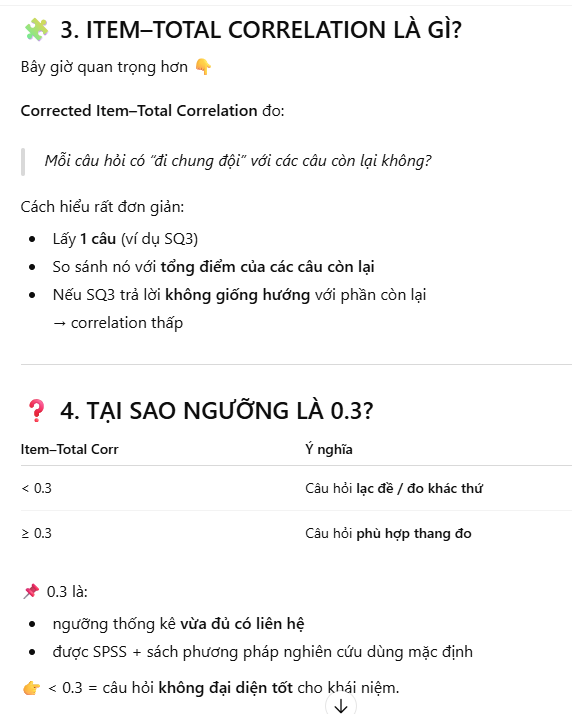

Độ tin cậy của thang đo được đánh giá thông qua hệ số Cronbach’s Alpha. Các biến quan sát có hệ số tương quan biến – tổng nhỏ hơn 0,3 sẽ bị loại khỏi mô hình nghiên cứu.


In [29]:
import numpy as np
import pandas as pd

def cronbach_alpha(df):
    df = df.dropna()
    k = df.shape[1]
    variances = df.var(ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - variances.sum() / total_var)
    return round(alpha, 3)

def item_total_correlation(df):
    df = df.dropna()
    total_score = df.sum(axis=1)
    
    result = []
    for col in df.columns:
        corr = df[col].corr(total_score - df[col])
        result.append([col, round(corr, 3)])
        
    return pd.DataFrame(
        result,
        columns=['Biến quan sát', 'Corrected Item-Total Correlation']
    )

def bang_cronbach_day_du(df, danh_sach_bien):
    df = df[danh_sach_bien].dropna()
    
    # Tính alpha
    alpha = cronbach_alpha(df)
    
    # Tính item–total correlation
    total_score = df.sum(axis=1)
    rows = []
    
    for col in df.columns:
        corr = df[col].corr(total_score - df[col])
        rows.append([
            col,
            round(corr, 3),
            alpha
        ])
        
    return pd.DataFrame(
        rows,
        columns=[
            'Biến quan sát',
            'Corrected Item-Total Correlation',
            'Cronbach’s Alpha'
        ]
    )

In [30]:
bang_cronbach_SQ = bang_cronbach_day_du(
    df,
    bien_quan_sat['Chất lượng hệ thống']
)
bang_cronbach_IQ = bang_cronbach_day_du(df, bien_quan_sat['Chất lượng thông tin'])
bang_cronbach_SVQ = bang_cronbach_day_du(df, bien_quan_sat['Chất lượng dịch vụ'])
bang_cronbach_PEOU = bang_cronbach_day_du(df, bien_quan_sat['Nhận thức về tính dễ sử dụng'])
bang_cronbach_PU = bang_cronbach_day_du(df, bien_quan_sat['Nhận thức về tính hữu ích'])
bang_cronbach_TR = bang_cronbach_day_du(df, bien_quan_sat['Niềm tin'])
bang_cronbach_CS = bang_cronbach_day_du(df, bien_quan_sat['Sự hài lòng'])



Bảng 4.6 trình bày kết quả kiểm định độ tin cậy của thang đo Chất lượng hệ thống.


In [33]:
print("4.3.1 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Chất lượng hệ thống")
bang_cronbach_SQ

4.3.1 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Chất lượng hệ thống


,Biến quan sát,Corrected Item-Total Correlation,Cronbach’s Alpha
0,SQ1,0.657,0.864
1,SQ2,0.740,0.864
2,SQ3,0.720,0.864
3,SQ4,0.697,0.864
4,SQ5,0.616,0.864


In [34]:
print("4.3.2 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Chất lượng thông tin")
bang_cronbach_IQ

4.3.2 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Chất lượng thông tin


,Biến quan sát,Corrected Item-Total Correlation,Cronbach’s Alpha
0,IQ1,0.720,0.856
1,IQ2,0.786,0.856
2,IQ3,0.554,0.856
3,IQ4,0.747,0.856


In [35]:
print("4.3.3 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Chất lượng dịch vụ")
bang_cronbach_SVQ

4.3.3 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Chất lượng dịch vụ


,Biến quan sát,Corrected Item-Total Correlation,Cronbach’s Alpha
0,SVQ1,0.671,0.899
1,SVQ2,0.709,0.899
2,SVQ3,0.808,0.899
3,SVQ4,0.783,0.899
4,SVQ5,0.780,0.899


In [36]:
print("4.3.4 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Nhận thức về tính dễ sử dụng")
bang_cronbach_PEOU

4.3.4 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Nhận thức về tính dễ sử dụng


,Biến quan sát,Corrected Item-Total Correlation,Cronbach’s Alpha
0,PEOU1,0.683,0.905
1,PEOU2,0.763,0.905
2,PEOU3,0.799,0.905
3,PEOU4,0.785,0.905
4,PEOU5,0.790,0.905


In [37]:
print("4.3.5 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Nhận thức về tính hữu ích")
bang_cronbach_PU

4.3.5 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Nhận thức về tính hữu ích


,Biến quan sát,Corrected Item-Total Correlation,Cronbach’s Alpha
0,PU1,0.770,0.904
1,PU2,0.807,0.904
2,PU3,0.787,0.904
3,PU4,0.772,0.904


In [39]:
print("4.3.6 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Niềm tin")
bang_cronbach_TR

4.3.6 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố độc lập Niềm tin


,Biến quan sát,Corrected Item-Total Correlation,Cronbach’s Alpha
0,TR1,0.718,0.907
1,TR2,0.728,0.907
2,TR3,0.733,0.907
3,TR4,0.760,0.907
4,TR5,0.760,0.907
5,TR6,0.767,0.907


In [40]:
print("4.3.7 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố phụ thuộc Sự hài lòng")
bang_cronbach_CS

4.3.7 Bảng hệ số Cronbach's Alpha và Item-Total Correlation yếu tố phụ thuộc Sự hài lòng


,Biến quan sát,Corrected Item-Total Correlation,Cronbach’s Alpha
0,CS1,0.760,0.901
1,CS2,0.807,0.901
2,CS3,0.787,0.901
3,CS4,0.761,0.901


## 4.4 Phân tích nhân tố khám phá (EFA)


Phân tích nhân tố khám phá được sử dụng nhằm đánh giá cấu trúc các thang đo và rút gọn các biến quan sát.


In [42]:
pip install factor_analyzer

     ---------------------------------------- 0.0/42.8 kB ? eta -:--:--
     --------- ------------------------------ 10.2/42.8 kB ? eta -:--:--
     ------------------ ------------------- 20.5/42.8 kB 320.0 kB/s eta 0:00:01
     -------------------------------------- 42.8/42.8 kB 346.6 kB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42717 sha256=808c0ffd9783351c1695f5e3406fd3b6b3b183d29b4d1f8394f73df18ba7b7cd
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\a2\af\06\f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer
Note: you may need to restart 


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Danh sách tất cả biến quan sát
bien_efa = (
    bien_quan_sat['Chất lượng hệ thống'] +
    bien_quan_sat['Chất lượng thông tin'] +
    bien_quan_sat['Chất lượng dịch vụ'] +
    bien_quan_sat['Nhận thức về tính dễ sử dụng'] +
    bien_quan_sat['Nhận thức về tính hữu ích'] +
    bien_quan_sat['Niềm tin'] +
    bien_quan_sat['Sự hài lòng']
)

df_efa = df[bien_efa]

In [50]:
# Chỉ lấy biến EFA
df_efa = df[bien_efa]

# Ép kiểu số
df_efa = df_efa.apply(pd.to_numeric, errors='coerce')

# Loại missing
df_efa = df_efa.dropna()

# Loại biến có phương sai = 0
df_efa = df_efa.loc[:, df_efa.var() > 0]

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_efa_scaled = pd.DataFrame(
    scaler.fit_transform(df_efa),
    columns=df_efa.columns
)

In [52]:
kmo_all, kmo_model = calculate_kmo(df_efa_scaled)
print("KMO =", round(kmo_model, 3))

chi_square_value, p_value = calculate_bartlett_sphericity(df_efa_scaled)
print("Bartlett’s Test p-value =", p_value)

KMO = 0.972
Bartlett’s Test p-value = 0.0


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [54]:
fa = FactorAnalyzer(rotation=None)
fa.fit(df_efa_scaled)

eigen_values, _ = fa.get_eigenvalues()

pd.DataFrame({
    'Nhân tố': range(1, len(eigen_values) + 1),
    'Eigenvalue': eigen_values
})

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Nhân tố,Eigenvalue
0,1,19.065818
1,2,1.813185
2,3,1.115817
3,4,0.838191
4,5,0.823946
5,6,0.698005
6,7,0.639423
7,8,0.558997
8,9,0.548885
9,10,0.497262


In [55]:
fa = FactorAnalyzer(n_factors=7, rotation='varimax')
fa.fit(df_efa_scaled)

loadings = pd.DataFrame(
    fa.loadings_,
    index=df_efa_scaled.columns,
    columns=[f'Factor{i+1}' for i in range(7)]
)

loadings.round(3)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7
SQ1,0.203,0.672,0.163,0.139,0.082,0.124,-0.043
SQ2,0.226,0.718,0.267,0.112,0.175,0.189,0.055
SQ3,0.219,0.713,0.185,0.177,0.219,-0.039,0.055
SQ4,0.432,0.534,0.237,0.236,0.117,0.013,-0.131
SQ5,0.694,0.366,0.114,0.133,0.167,0.104,0.004
IQ1,0.720,0.234,0.289,0.114,0.027,0.086,0.130
IQ2,0.713,0.227,0.247,0.190,0.125,-0.054,0.258
IQ3,0.226,0.508,0.289,0.355,0.165,0.136,0.277
IQ4,0.692,0.225,0.297,0.250,0.132,-0.074,0.113
SVQ1,0.643,0.199,0.311,0.377,-0.043,0.140,-0.122


In [53]:
fa = FactorAnalyzer(n_factors=7, rotation='varimax')
fa.fit(df_efa_scaled)

loadings = pd.DataFrame(
    fa.loadings_,
    index=df_efa_scaled.columns,
    columns=[f'Factor{i+1}' for i in range(7)]
)

loadings.round(3)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7
SQ1,0.203,0.672,0.163,0.139,0.082,0.124,-0.043
SQ2,0.226,0.718,0.267,0.112,0.175,0.189,0.055
SQ3,0.219,0.713,0.185,0.177,0.219,-0.039,0.055
SQ4,0.432,0.534,0.237,0.236,0.117,0.013,-0.131
SQ5,0.694,0.366,0.114,0.133,0.167,0.104,0.004
IQ1,0.720,0.234,0.289,0.114,0.027,0.086,0.130
IQ2,0.713,0.227,0.247,0.190,0.125,-0.054,0.258
IQ3,0.226,0.508,0.289,0.355,0.165,0.136,0.277
IQ4,0.692,0.225,0.297,0.250,0.132,-0.074,0.113
SVQ1,0.643,0.199,0.311,0.377,-0.043,0.140,-0.122


## 4.5 Phân tích hồi quy tuyến tính


Phân tích hồi quy tuyến tính được sử dụng nhằm đánh giá mức độ ảnh hưởng của các nhân tố đến sự hài lòng của khách hàng.
